In [56]:
pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [57]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score

In [58]:
df = pd.read_csv("Cleaned_Dataset.csv")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [59]:

df['FraudFlag'] = df['OrderStatus'].apply(lambda x: 1 if x in ['Cancelled','Returned'] else 0)

In [60]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,FraudFlag
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,0
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,0
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,1
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,0


In [61]:
X = df.drop(columns=['FraudFlag','OrderID','CustomerID','ShippingAddress','TrackingNumber'])
y = df['FraudFlag']

In [62]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [63]:
df['FraudFlag'] = df['OrderStatus'].apply(lambda x: 1 if x in ['Cancelled','Returned'] else 0)

X = df.drop(columns=['FraudFlag','OrderID','CustomerID','ShippingAddress','TrackingNumber'])
y = df['FraudFlag']

# Date ko PEHLE date bana lo, aur uska string version drop kar do
X['Date'] = pd.to_datetime(X['Date'])
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month
X['Day'] = X['Date'].dt.day
X = X.drop(columns=['Date'])   # ab is Date ko dummies mein nahi jaane dena

# ab get_dummies chalao — ab Date wahan nahi hai
X = pd.get_dummies(X, drop_first=True)

In [64]:
X = pd.get_dummies(X, drop_first=True)

In [65]:
X['Date'] = pd.to_datetime(df['Date'])
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month
X['Day'] = X['Date'].dt.day
X = X.drop(columns=['Date'])

In [66]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [67]:
#Handle imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [68]:

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])
lr_pipeline.fit(X_train_res, y_train_res)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['Quantity','UnitPrice','ItemsInCart',...,'ReferralSource_Google', 'ReferralSource_Instagram','ReferralSource_Referral']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [69]:
rf_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train_res, y_train_res)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['Quantity','UnitPrice','ItemsInCart',...,'ReferralSource_Google', 'ReferralSource_Instagram','ReferralSource_Referral']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'


In [70]:
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

In [71]:
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("ROC-AUC (LR):", roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:,1]))

print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC (RF):", roc_auc_score(y_test, rf_pipeline.predict_proba(X_test)[:,1]))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       141
           1       1.00      1.00      1.00        99

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

ROC-AUC (LR): 1.0
Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       141
           1       1.00      1.00      1.00        99

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

ROC-AUC (RF): 1.0


Logistic Regression Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       141
           1       1.00      1.00      1.00        99

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

ROC-AUC (LR): 1.0
Confusion Matrix (LR):
 [[141   0]
 [  0  99]]
Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       141
           1       1.00      1.00      1.00        99

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

ROC-AUC (RF): 1.0
Confusion Matrix (RF):
 [[141   0]
 [  0  99]]


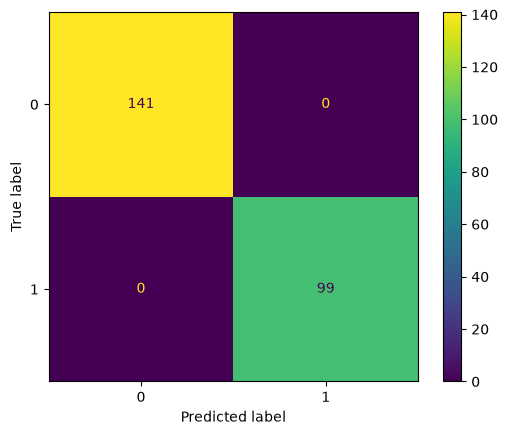

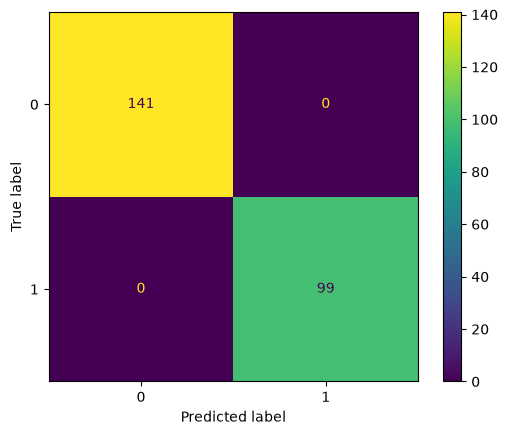

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Logistic Regression Evaluation
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("ROC-AUC (LR):", roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:,1]))

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()
print("Confusion Matrix (LR):\n", cm_lr)

# Random Forest Evaluation
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC (RF):", roc_auc_score(y_test, rf_pipeline.predict_proba(X_test)[:,1]))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
print("Confusion Matrix (RF):\n", cm_rf)


In [73]:
# Compare metrics side by side
results = {
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf_pipeline.predict_proba(X_test)[:,1])
    ]
}

import pandas as pd
print(pd.DataFrame(results))


                 Model  ROC-AUC
0  Logistic Regression      1.0
1        Random Forest      1.0


In [74]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='roc_auc')
print("Cross-Validation ROC-AUC scores:", scores)
print("Mean ROC-AUC:", scores.mean())


Cross-Validation ROC-AUC scores: [1. 1. 1. 1. 1.]
Mean ROC-AUC: 1.0


In [75]:
import numpy as np
feature_importances = rf_pipeline.named_steps['classifier'].feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
print(importance_df.sort_values(by='Importance', ascending=False).head(10))


                  Feature  Importance
20    OrderStatus_Shipped    0.208219
19   OrderStatus_Returned    0.206814
18    OrderStatus_Pending    0.199728
17  OrderStatus_Delivered    0.184113
1               UnitPrice    0.030240
3              TotalPrice    0.026873
5                   Month    0.023488
6                     Day    0.022104
2             ItemsInCart    0.016235
0                Quantity    0.010475


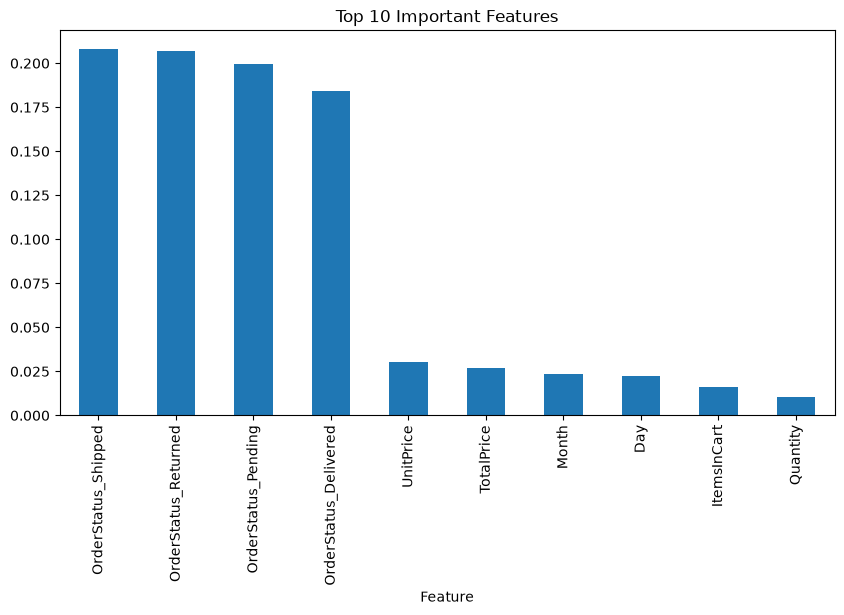

In [76]:
import matplotlib.pyplot as plt

importance_df.sort_values(by='Importance', ascending=False).head(10).plot(
    x='Feature', y='Importance', kind='bar', figsize=(10,5), legend=False
)
plt.title("Top 10 Important Features")
plt.show()


In [77]:
import joblib
joblib.dump(rf_pipeline, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [78]:
model = joblib.load("fraud_detection_model.pkl")

new_data = pd.DataFrame({
    "Quantity":[2],
    "UnitPrice":[500],
    "TotalPrice":[1000],
    "ItemsInCart":[1],
    "Month":[9],
    "Day":[6],
    "OrderStatus_Delivered":[1],
    "OrderStatus_Returned":[0],
    "OrderStatus_Pending":[0],
    "OrderStatus_Shipped":[0]
})

# YEH LINE MAGIC KAREGI — missing columns 0 se fill ho jayenge, order bhi match hoga
new_data = new_data.reindex(columns=model_columns, fill_value=0)

prediction = model.predict(new_data)
print("Fraud Prediction:", prediction)

Fraud Prediction: [0]
